# Классификация английских текстов по уровню CEFR с помощью нейронной сети

**Предметная область:** поддержка изучения иностранного языка. Приложение для изучения языка должно предоставлять ученику тексты, соответствующие его уровню: слишком простые не обучают, а слишком сложные отбивают мотивацию. Ручная разметка большой библиотеки текстов нереальна, поэтому актуальна задача автоматической оценки уровня текста.

**Задача:** классификация английских текстов по уровню CEFR. Шесть исходных уровней укрупнены до трёх классов — A (начальный), B (средний), C (продвинутый): такое деление педагогически осмысленно и соответствует тому, как языковые приложения сегментируют учеников.

**Источник данных:** публичный датасет «CEFR Levelled English Texts» (Kaggle, amontgomerie), загружается в коде через `kagglehub`.

**Цель:** разработать нейронную сеть для автоматической классификации английских текстов по уровню сложности CEFR.

**Задачи:**
- закрепить приобретённые теоретические знания;
- приобрести опыт разработки нейронных сетей на языке Python;
- использовать отечественные и международные стандарты при решении прикладных задач;
- составить требования к информационной системе на основе анализа предметной области;
- разработать математическую модель нейронной сети;
- выполнить сбор и нормализацию данных для обучения нейронной сети;
- обучить нейронную сеть для решения поставленной задачи;
- получить навыки самостоятельной работы;
- подготовить отчётную документацию.

## 0. Подготовка окружения

Устанавливаем все библиотеки, которые понадобятся в работе, одной командой. Флаг `-q` убирает лишний вывод.

In [59]:
%pip install -q kagglehub pandas numpy scikit-learn textstat nltk certifi torch matplotlib seaborn

439324.39s - pydevd: Sending message related to process being replaced timed-out after 5 seconds



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Библиотека `textstat` для подсчёта слогов использует словарь произношения `cmudict` из пакета `nltk` и скачивает его из интернета. На macOS Python по умолчанию не видит системные SSL-сертификаты, поэтому подставляем набор сертификатов из пакета `certifi` и скачиваем словарь.

In [60]:
import ssl, certifi, nltk

ssl._create_default_https_context = lambda: ssl.create_default_context(cafile=certifi.where())
nltk.download('cmudict', quiet=True)

True

## 1. Загрузка данных

Скачиваем датасет с Kaggle через `kagglehub` — данные загружаются прямо из кода, поэтому ноутбук запускается на любой машине без ручного скачивания файлов. Затем находим в скачанной папке CSV-файл и читаем его в таблицу `pandas`.

In [61]:
import os
import kagglehub
import pandas as pd

path = kagglehub.dataset_download("amontgomerie/cefr-levelled-english-texts")
print("Данные скачаны:", path)

csv_files = sorted(f for f in os.listdir(path) if f.endswith('.csv'))
file_path = os.path.join(path, csv_files[0])
df = pd.read_csv(file_path)
print("Файл:", csv_files[0])

Данные скачаны: /Users/humay/.cache/kagglehub/datasets/amontgomerie/cefr-levelled-english-texts/versions/1
Файл: cefr_leveled_texts.csv


Смотрим размер таблицы и первые строки: в датасете две колонки — `text` (текст) и `label` (уровень CEFR от A1 до C2).

In [62]:
print("Объём датасета (строки, колонки):", df.shape)
display(df.head())

Объём датасета (строки, колонки): (1494, 2)


,text,label
0,Hi!\nI've been meaning to write for ages and f...,B2
1,﻿It was not so much how hard people found the ...,B2
2,Keith recently came back from a trip to Chicag...,B2
3,"The Griffith Observatory is a planetarium, and...",B2
4,-LRB- The Hollywood Reporter -RRB- It's offici...,B2


Укрупняем уровни: из метки оставляем только первую букву (A1, A2 → A; B1, B2 → B; C1, C2 → C) и считаем, сколько текстов попало в каждый класс.

In [63]:
df['label'] = df['label'].str[0]

class_counts = df['label'].value_counts().sort_index()
print("Баланс классов:")
display(class_counts)

Баланс классов:


label
A    560
B    491
C    443
Name: count, dtype: int64

**Вывод по первичному анализу данных.** Датасет содержит 1494 текста. После укрупнения уровней до трёх классов получено распределение: A — 560 текстов, B — 491, C — 443. Соотношение самого крупного и самого малого класса — 1,26 : 1, критического дисбаланса нет, дополнительная балансировка не требуется.

## 2. Признаки сложности текста

Нейронная сеть не может работать с текстом напрямую — ей нужны числа. Для каждого текста вычисляем 12 числовых признаков, описывающих его сложность:

- **простые признаки** — число слов и предложений, средняя длина предложения и слова, доля длинных слов (больше 6 букв), лексическое разнообразие (доля уникальных слов);
- **формулы читаемости** из библиотеки `textstat` — индекс удобочитаемости Флеша, индекс Флеша–Кинкейда, индекс Ганнинга, SMOG, индекс Дейла–Челла и доля «трудных» слов.

Результат — таблица `X_feat`: 1494 строки и 12 колонок.

In [64]:
import re
import numpy as np
import textstat

def text_features(t):
    sents = [s for s in re.split(r'[.!?]+', t) if s.strip()]
    words = re.findall(r"[A-Za-z']+", t)
    n_w, n_s = max(len(words), 1), max(len(sents), 1)
    return {
        'n_words': len(words),
        'n_sents': len(sents),
        'avg_sent_len': n_w / n_s,
        'avg_word_len': np.mean([len(w) for w in words]) if words else 0,
        'long_word_ratio': sum(len(w) > 6 for w in words) / n_w,
        'lex_diversity': len(set(w.lower() for w in words)) / n_w,
        'flesch': textstat.flesch_reading_ease(t),
        'fk_grade': textstat.flesch_kincaid_grade(t),
        'gunning_fog': textstat.gunning_fog(t),
        'smog': textstat.smog_index(t),
        'dale_chall': textstat.dale_chall_readability_score(t),
        'difficult_words_ratio': textstat.difficult_words(t) / n_w,
    }

X_feat = df['text'].apply(text_features).apply(pd.Series)
print("Таблица признаков:", X_feat.shape)
display(X_feat.describe().round(2))

Таблица признаков: (1494, 12)


,n_words,n_sents,avg_sent_len,avg_word_len,long_word_ratio,lex_diversity,flesch,fk_grade,gunning_fog,smog,dale_chall,difficult_words_ratio
count,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00,1494.00
mean,413.53,26.45,14.54,4.46,0.19,0.52,67.57,7.65,9.82,10.32,8.87,0.15
std,324.27,14.60,6.90,0.48,0.08,0.10,21.39,4.61,5.01,3.70,2.00,0.07
min,34.00,1.00,2.69,3.03,0.00,0.21,-8.62,-1.57,1.69,3.13,0.25,0.00
25%,125.00,17.00,7.73,4.09,0.12,0.46,52.28,3.55,5.14,7.17,7.27,0.08
50%,307.00,23.00,14.65,4.52,0.20,0.50,63.99,8.33,10.39,10.95,9.09,0.16
75%,615.75,32.00,19.57,4.81,0.25,0.56,86.39,10.89,13.54,13.09,10.43,0.21
max,2235.00,123.00,45.56,6.00,0.42,0.94,114.26,30.01,33.58,23.73,21.32,0.44


## 3. Разведочный анализ

Строим диаграммы размаха («ящик с усами»): как распределён каждый признак внутри уровней A, B и C. Линия внутри ящика — медиана, сам ящик — средние 50% текстов, усы — обычный разброс, кружки — выбросы. Если ящики разных уровней стоят на разной высоте и почти не перекрываются, признак хорошо различает уровни.

Затем строим матрицу корреляций — насколько признаки связаны друг с другом.

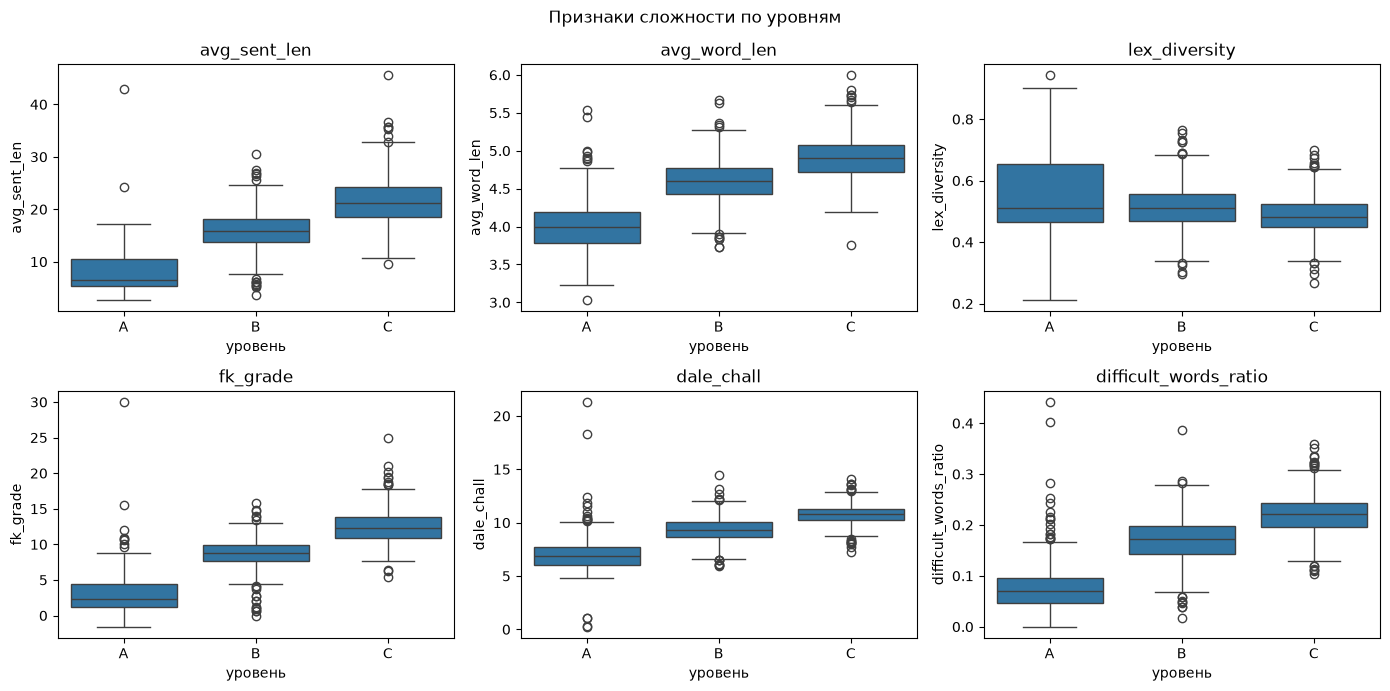

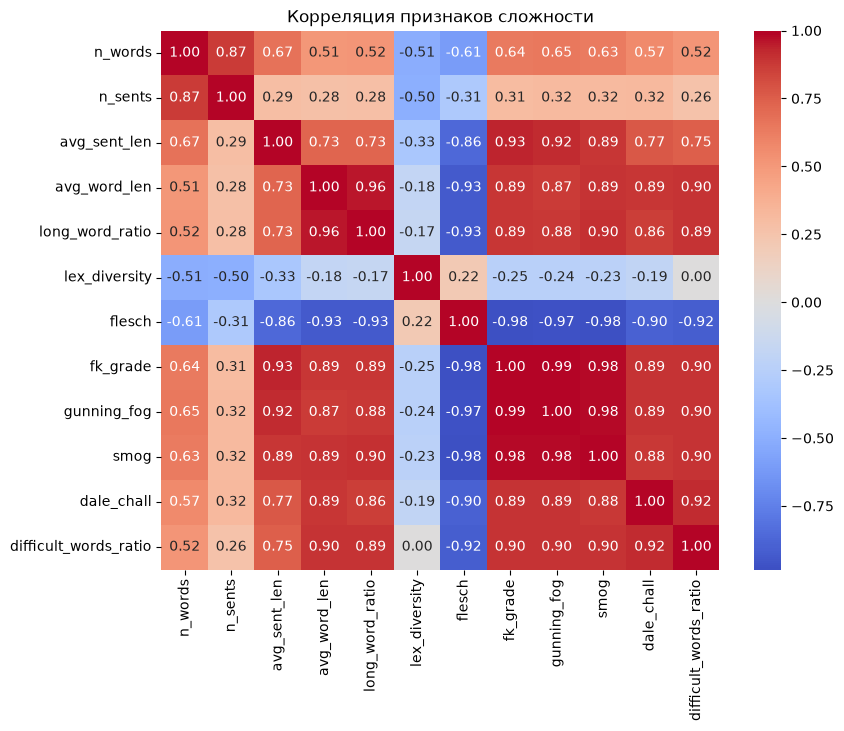

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

feat_df = X_feat.copy()
feat_df['уровень'] = df['label'].values

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, ['avg_sent_len', 'avg_word_len', 'lex_diversity',
                                'fk_grade', 'dale_chall', 'difficult_words_ratio']):
    sns.boxplot(data=feat_df, x='уровень', y=col, order=['A', 'B', 'C'], ax=ax)
    ax.set_title(col)
plt.suptitle('Признаки сложности по уровням'); plt.tight_layout(); plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(X_feat.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Корреляция признаков сложности'); plt.show()

**Вывод по диаграммам размаха.** Большинство признаков монотонно растут от уровня A к уровню C. Сильнее всего классы разделяет средняя длина предложения: медиана около 7 слов у A, 16 у B и 21 у C. Так же чётко растут средняя длина слова (4,0 → 4,6 → 4,9), индекс Флеша–Кинкейда и доля сложных слов. Уровень A отделён от остальных почти без пересечений, а B и C пересекаются заметно сильнее — поэтому основные ошибки модели ожидаются между средним и продвинутым уровнем. Исключение — лексическое разнообразие: оно почти не различает уровни, а его большой разброс у A объясняется тем, что в коротких текстах доля уникальных слов завышена.

**Вывод по матрице корреляций.** Формулы читаемости (Флеш, Флеш–Кинкейд, Ганнинг, SMOG, Дейл–Челл) сильно коррелируют друг с другом (|r| от 0,88 до 0,99), поскольку все они вычисляются из одних и тех же величин — длины предложений и длины слов. Признаки во многом дублируют друг друга. Лексическое разнообразие, напротив, почти не связано с остальными признаками и несёт отдельную информацию.

## 4. Базовые модели

Прежде чем строить нейросеть, проверяем, какую точность дают простые модели. Это ориентир: нейросеть должна быть не хуже.

Первая модель — «мешок слов»: текст превращается в вектор частот слов и словосочетаний (TF-IDF, 5000 признаков), по нему обучается логистическая регрессия. Точность оцениваем кросс-валидацией на 5 частях: модель 5 раз обучается на 4/5 данных и проверяется на оставшейся 1/5, результат усредняется.

In [66]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

pipe = make_pipeline(
    TfidfVectorizer(max_features=5000, ngram_range=(1, 2), sublinear_tf=True),
    LogisticRegression(max_iter=1000, C=1.0)
)
scores = cross_val_score(pipe, df['text'], df['label'], cv=5, scoring='accuracy')
print(f"TF-IDF + логистическая регрессия: {scores.mean():.3f} ± {scores.std():.3f}")

TF-IDF + логистическая регрессия: 0.842 ± 0.049


Те же проверки на 12 признаках сложности: логистическая регрессия (признаки предварительно нормализуются) и случайный лес.

In [67]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

for name, clf in [
    ('Логистическая регрессия на признаках сложности', make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))),
    ('Случайный лес на признаках сложности', RandomForestClassifier(n_estimators=300, random_state=42)),
]:
    s = cross_val_score(clf, X_feat, df['label'], cv=5, scoring='accuracy')
    print(f"{name}: {s.mean():.3f} ± {s.std():.3f}")

Логистическая регрессия на признаках сложности: 0.845 ± 0.063
Случайный лес на признаках сложности: 0.861 ± 0.051


**Вывод по базовым моделям.** На трёх классах слова (TF-IDF + логистическая регрессия) даёт 0,842 ± 0,049, двенадцать признаков сложности — 0,845 ± 0,063 с той же моделью и 0,861 ± 0,051 со случайным лесом. Лексика и структура текста несут сопоставимый сигнал об уровне. Для нейросети выбраны признаки сложности: при той же точности это 12 входов вместо 5000, что снижает риск переобучения на выборке из 1045 обучающих текстов, а сами признаки интерпретируемы — по ним видно, чем тексты разных уровней отличаются друг от друга.

## 5. Подготовка данных для нейросети

Переводим буквы классов в числа (A → 0, B → 1, C → 2) и делим данные на три части с сохранением пропорций классов:
- **обучающая** (70%) — на ней сеть учится;
- **валидационная** (15%) — по ней решаем, когда остановить обучение;
- **тестовая** (15%) — на ней один раз измеряем итоговое качество.

Затем нормализуем признаки (приводим к среднему 0 и стандартному отклонению 1), чтобы признаки с большими значениями не подавляли остальные. Нормализатор обучается **только на обучающей выборке**, иначе информация из тестовых данных «утекла» бы в модель.

In [68]:
from sklearn.model_selection import train_test_split

label_map = {'A': 0, 'B': 1, 'C': 2}
y = df['label'].map(label_map).values
X = X_feat.values.astype('float32')

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

scaler = StandardScaler().fit(X_train)
X_train, X_val, X_test = scaler.transform(X_train), scaler.transform(X_val), scaler.transform(X_test)
print('обучение / валидация / тест:', X_train.shape, X_val.shape, X_test.shape)

обучение / валидация / тест: (1045, 12) (224, 12) (225, 12)


Упаковываем данные в формат PyTorch. Класс `CEFRDataset` превращает массивы в тензоры и отдаёт по одному примеру. `DataLoader` собирает примеры в пакеты (батчи) по 64 штуки; обучающие данные перемешиваются перед каждой эпохой, чтобы сеть не запоминала порядок. `torch.manual_seed(42)` фиксирует генератор случайных чисел, чтобы результат повторялся при каждом запуске.

In [69]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

torch.manual_seed(42)

class CEFRDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, i):
        return self.X[i], self.y[i]

batch_size = 64
train_loader = DataLoader(CEFRDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(CEFRDataset(X_val, y_val), batch_size=batch_size)
test_loader  = DataLoader(CEFRDataset(X_test, y_test), batch_size=batch_size)

## 6. Нейронная сеть

Многослойный перцептрон (MLP): 12 входов → скрытый слой на 64 нейрона → скрытый слой на 32 нейрона → 3 выхода (по одному на уровень).

- `Linear` — полносвязный слой: y = Wx + b;
- `ReLU` — функция активации: max(0, x), добавляет нелинейность;
- `Dropout(0.3)` — при обучении случайно отключает 30% нейронов, чтобы сеть не переобучалась;
- на выходе три числа; функция `softmax`, встроенная в функцию потерь `CrossEntropyLoss`, превращает их в вероятности классов.

In [70]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden=(64, 32), dropout=0.3, n_classes=3):
        super().__init__()
        layers, prev = [], n_in
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

model = MLP(n_in=X_train.shape[1])
print(model)
print('обучаемых параметров:', sum(p.numel() for p in model.parameters()))

MLP(
  (net): Sequential(
    (0): Linear(in_features=12, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=3, bias=True)
  )
)
обучаемых параметров: 3011


Обучение. Функция `run_epoch` проходит по всем данным один раз (одна эпоха): считает предсказания, ошибку (функцию потерь) и, если идёт обучение, обновляет веса сети методом обратного распространения ошибки. Функция `train_model` повторяет эпохи и после каждой проверяет качество на валидации.

- оптимизатор **Adam** со скоростью обучения 0,001;
- **ранняя остановка**: если 15 эпох подряд потери на валидации не уменьшаются, обучение прекращается, и восстанавливаются веса лучшей эпохи;
- записывается история потерь и точности по эпохам и замеряется время обучения.

In [71]:
import time

def run_epoch(model, loader, loss_fn, optimizer=None):
    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for xb, yb in loader:
            out = model(xb)
            loss = loss_fn(out, yb)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct += (out.argmax(1) == yb).sum().item()
            n += len(yb)
    return total_loss / n, correct / n

def train_model(model, epochs=200, lr=1e-3, patience=15):
    loss_fn = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_state, wait = float('inf'), None, 0
    t0 = time.perf_counter()
    for epoch in range(epochs):
        tl, ta = run_epoch(model, train_loader, loss_fn, optimizer)
        vl, va = run_epoch(model, val_loader, loss_fn)
        for key, val in zip(history, (tl, vl, ta, va)):
            history[key].append(val)
        if vl < best_val:
            best_val, wait = vl, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    print(f'обучение: {epoch + 1} эпох, {time.perf_counter() - t0:.1f} с')
    return history

history = train_model(model)
test_loss, test_acc = run_epoch(model, test_loader, nn.CrossEntropyLoss())
print(f'accuracy на тесте: {test_acc:.3f}')

обучение: 82 эпох, 1.4 с
accuracy на тесте: 0.867


Графики обучения: как менялись потери и точность на обучающей и валидационной выборках от эпохи к эпохе.

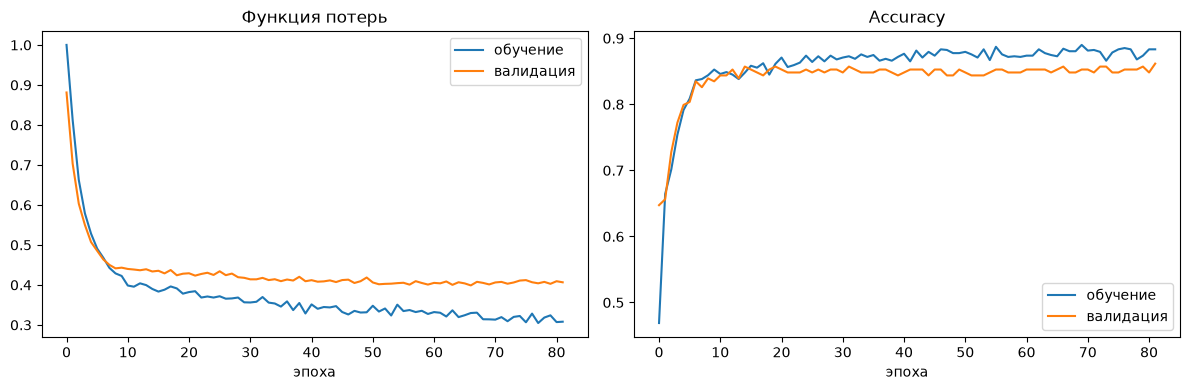

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history['train_loss'], label='обучение')
ax[0].plot(history['val_loss'], label='валидация')
ax[0].set_title('Функция потерь'); ax[0].set_xlabel('эпоха'); ax[0].legend()
ax[1].plot(history['train_acc'], label='обучение')
ax[1].plot(history['val_acc'], label='валидация')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('эпоха'); ax[1].legend()
plt.tight_layout(); plt.show()

**Вывод по обучению.** Сеть быстро обучается: за первые 10 эпох точность растёт с 0,47 до 0,84. Примерно с 15-й эпохи потери на валидации выходят на плато около 0,41, а на обучающей выборке продолжают снижаться до 0,31 — начинается лёгкое переобучение. Разрыв небольшой (около 3% по точности) благодаря Dropout, а ранняя остановка завершила обучение на 82-й эпохе.

## 7. Оценка модели на тестовой выборке

Кроме общей точности смотрим метрики по каждому классу:
- **precision** — из текстов, которые модель отнесла к классу, какая доля действительно из него;
- **recall** — из текстов класса, какую долю модель нашла;
- **F1** — среднее гармоническое precision и recall.

Матрица ошибок показывает, какие уровни модель путает между собой: по строкам — истинный уровень, по столбцам — предсказанный.

              precision    recall  f1-score   support

           A      0.920     0.952     0.936        84
           B      0.797     0.797     0.797        74
           C      0.875     0.836     0.855        67

    accuracy                          0.867       225
   macro avg      0.864     0.862     0.863       225
weighted avg      0.866     0.867     0.866       225



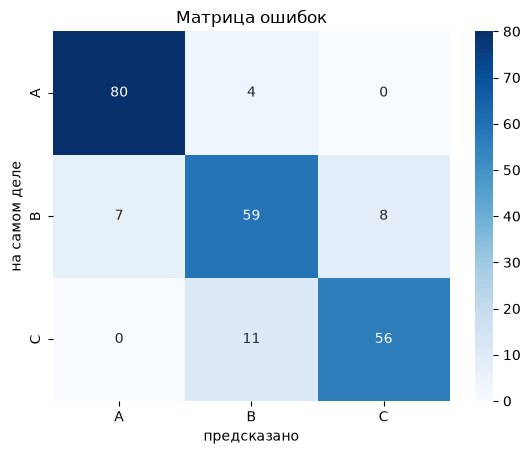

In [73]:
from sklearn.metrics import classification_report, confusion_matrix

def predict(model, loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for xb, yb in loader:
            preds.append(model(xb).argmax(1))
            trues.append(yb)
    return torch.cat(trues).numpy(), torch.cat(preds).numpy()

y_true, y_pred = predict(model, test_loader)
print(classification_report(y_true, y_pred, target_names=['A', 'B', 'C'], digits=3))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['A', 'B', 'C'], yticklabels=['A', 'B', 'C'])
plt.xlabel('предсказано'); plt.ylabel('на самом деле'); plt.title('Матрица ошибок')
plt.show()

**Вывод по оценке.** Точность на тестовой выборке — 0,867, порог 0,70 превышен. Лучше всего модель распознаёт уровень A (recall 0,952, F1 0,936). Сложнее всего средний уровень B (F1 0,797): он граничит с обоими соседними уровнями, и ошибки идут в обе стороны. Это совпадает с диаграммами размаха, где уровни B и C перекрываются сильнее всего.

## 8. Улучшение модели

Проверяем три направления улучшения. Функция `fit_eval` обучает сеть с заданными настройками и возвращает точность на тесте, число эпох, время и число параметров.

1. **Гиперпараметры** — скорость обучения (lr), доля отключаемых нейронов (dropout), размер пакета (batch).
2. **Топология** — число скрытых слоёв и нейронов в них.
3. **Данные** — а) только 6 простых признаков без формул читаемости; б) 12 признаков вместе с TF-IDF по 300 самым частым словам.

,направление,вариант,accuracy,эпох,"время, с",параметров
0,гиперпараметры,lr=0.01,0.876,24,0.41,3011
1,гиперпараметры,lr=0.001,0.867,82,1.08,3011
2,гиперпараметры,lr=0.0001,0.871,200,2.85,3011
3,гиперпараметры,dropout=0.1,0.876,87,1.12,3011
4,гиперпараметры,dropout=0.5,0.871,72,0.92,3011
5,гиперпараметры,batch=32,0.862,68,1.36,3011
6,гиперпараметры,batch=128,0.871,102,0.89,3011
7,топология,"слои (32,)",0.884,108,1.12,515
8,топология,"слои (64, 32)",0.867,82,1.02,3011
9,топология,"слои (128, 64, 32)",0.862,46,0.73,12099


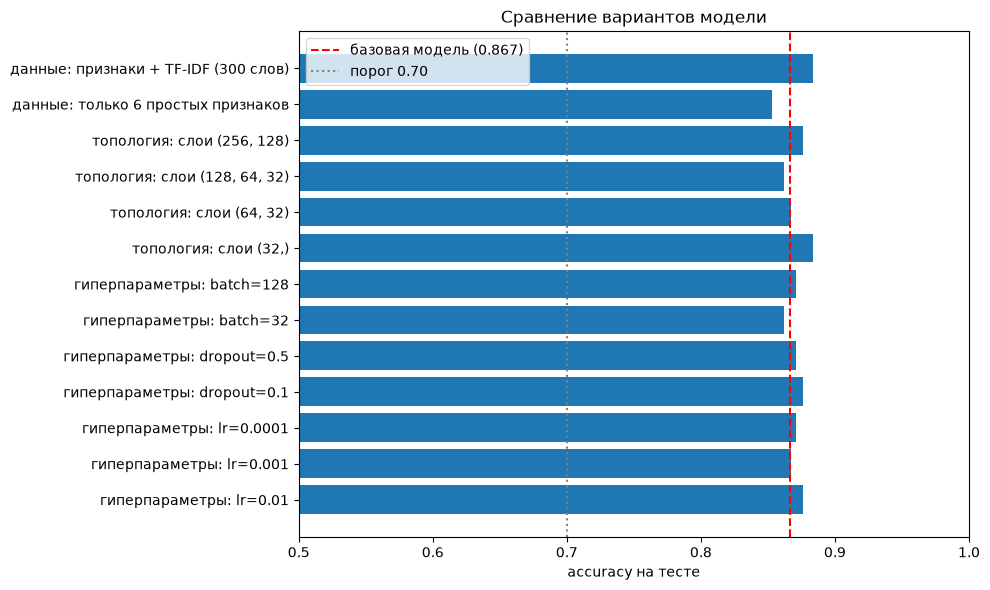

In [74]:
def fit_eval(Xtr, ytr, Xva, yva, Xte, yte, hidden=(64, 32), dropout=0.3, lr=1e-3,
             batch_size=64, epochs=200, patience=15):
    torch.manual_seed(42)
    tr = DataLoader(CEFRDataset(Xtr, ytr), batch_size=batch_size, shuffle=True)
    va = DataLoader(CEFRDataset(Xva, yva), batch_size=batch_size)
    te = DataLoader(CEFRDataset(Xte, yte), batch_size=batch_size)
    m = MLP(n_in=Xtr.shape[1], hidden=hidden, dropout=dropout)
    loss_fn = nn.CrossEntropyLoss()
    opt = torch.optim.Adam(m.parameters(), lr=lr)
    best, best_state, wait = float('inf'), None, 0
    t0 = time.perf_counter()
    for epoch in range(epochs):
        run_epoch(m, tr, loss_fn, opt)
        vl, _ = run_epoch(m, va, loss_fn)
        if vl < best:
            best, wait = vl, 0
            best_state = {k: v.clone() for k, v in m.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    secs = time.perf_counter() - t0
    m.load_state_dict(best_state)
    _, acc = run_epoch(m, te, loss_fn)
    return {'accuracy': round(acc, 3), 'эпох': epoch + 1, 'время, с': round(secs, 2),
            'параметров': sum(p.numel() for p in m.parameters())}

D = (X_train, y_train, X_val, y_val, X_test, y_test)
results = []

# 1. Гиперпараметры
for lr in [1e-2, 1e-3, 1e-4]:
    results.append({'направление': 'гиперпараметры', 'вариант': f'lr={lr}', **fit_eval(*D, lr=lr)})
for dp in [0.1, 0.5]:
    results.append({'направление': 'гиперпараметры', 'вариант': f'dropout={dp}', **fit_eval(*D, dropout=dp)})
for bs in [32, 128]:
    results.append({'направление': 'гиперпараметры', 'вариант': f'batch={bs}', **fit_eval(*D, batch_size=bs)})

# 2. Топология
for h in [(32,), (64, 32), (128, 64, 32), (256, 128)]:
    results.append({'направление': 'топология', 'вариант': f'слои {h}', **fit_eval(*D, hidden=h)})

# 3а. Данные: только 6 простых признаков
results.append({'направление': 'данные', 'вариант': 'только 6 простых признаков',
                **fit_eval(X_train[:, :6], y_train, X_val[:, :6], y_val, X_test[:, :6], y_test)})

# 3б. Данные: признаки сложности + TF-IDF по словам
idx = np.arange(len(df))
i_train, i_temp = train_test_split(idx, test_size=0.3, stratify=y, random_state=42)
i_val, i_test = train_test_split(i_temp, test_size=0.5, stratify=y[i_temp], random_state=42)
texts = df['text'].values
scaler2 = StandardScaler().fit(X[i_train])
tfidf = TfidfVectorizer(max_features=300, ngram_range=(1, 2), sublinear_tf=True).fit(texts[i_train])

def combo(ix):
    return np.hstack([scaler2.transform(X[ix]), tfidf.transform(texts[ix]).toarray()])

results.append({'направление': 'данные', 'вариант': 'признаки + TF-IDF (300 слов)',
                **fit_eval(combo(i_train), y[i_train], combo(i_val), y[i_val], combo(i_test), y[i_test])})

res = pd.DataFrame(results)
display(res)

plt.figure(figsize=(10, 6))
plt.barh(res['направление'] + ': ' + res['вариант'], res['accuracy'])
plt.axvline(test_acc, color='red', linestyle='--', label=f'базовая модель ({test_acc:.3f})')
plt.axvline(0.7, color='gray', linestyle=':', label='порог 0.70')
plt.xlim(0.5, 1.0); plt.xlabel('accuracy на тесте'); plt.legend()
plt.title('Сравнение вариантов модели'); plt.tight_layout(); plt.show()

**Вывод по улучшениям.** Все 13 вариантов показали точность в диапазоне 0,853–0,884, и все превышают порог 0,70. Тестовая выборка содержит 225 текстов, поэтому стандартная ошибка оценки точности составляет примерно ±0,022 — различия между вариантами укладываются в неё и статистически неразличимы. Модель устойчива к выбору гиперпараметров, а качество ограничено данными и их разметкой, а не архитектурой.

Скорость обучения влияет на скорость сходимости, но не на итоговое качество: при lr = 0,01 обучение заняло 24 эпохи, при lr = 0,0001 — все 200, при почти одинаковой точности.

Минимальная сеть с одним скрытым слоем на 32 нейрона (515 параметров) показала лучший результат — 0,884, при том что у сети (256, 128) параметров в 70 раз больше. Для 12 входных признаков более сложная архитектура не нужна.

Удаление шести формул читаемости снизило точность всего на 1,4% (0,867 → 0,853), что согласуется с матрицей корреляций: формулы почти дублируют простые признаки длины. Добавление TF-IDF по словам дало 0,884 и самую быструю сходимость (31 эпоха): лексика и структура текста дополняют друг друга.

### Скорость обучения как функция топологии

Общее время обучения зависит от числа эпох до ранней остановки, которое у вариантов разное. Поэтому сравниваем время **одной эпохи**.

,вариант,параметров,эпох,"время, с",с / эпоха
7,"слои (32,)",515,108,1.12,0.0104
8,"слои (64, 32)",3011,82,1.02,0.0124
9,"слои (128, 64, 32)",12099,46,0.73,0.0159
10,"слои (256, 128)",36611,65,1.13,0.0174


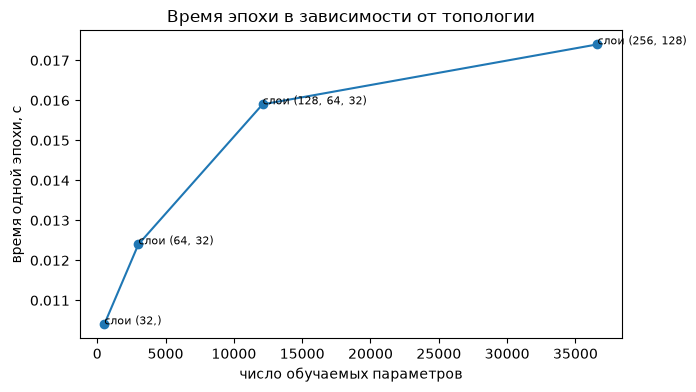

In [75]:
topo = res[res['направление'] == 'топология'].copy()
topo['с / эпоха'] = (topo['время, с'] / topo['эпох']).round(4)
display(topo[['вариант', 'параметров', 'эпох', 'время, с', 'с / эпоха']])

plt.figure(figsize=(7, 4))
plt.plot(topo['параметров'], topo['с / эпоха'], marker='o')
for _, r in topo.iterrows():
    plt.annotate(r['вариант'], (r['параметров'], r['с / эпоха']), fontsize=8)
plt.xlabel('число обучаемых параметров'); plt.ylabel('время одной эпохи, с')
plt.title('Время эпохи в зависимости от топологии'); plt.show()

**Вывод.** Время одной эпохи растёт с числом обучаемых параметров. Общее время обучения при этом зависит от топологии немонотонно, поскольку ранняя остановка срабатывает на разной эпохе.

## Итоги

- Датасет из 1494 английских текстов укрупнён до трёх уровней CEFR; классы сбалансированы.
- Для каждого текста вычислено 12 признаков сложности; разведочный анализ показал, что большинство из них монотонно растут от уровня A к C, а формулы читаемости сильно коррелируют между собой.
- Базовые модели дают 0,84–0,86; для нейросети выбраны признаки сложности как компактное и интерпретируемое представление.
- Многослойный перцептрон (12 → 64 → 32 → 3, 3011 параметров) достиг точности 0,867 на тестовой выборке при пороге 0,70.
- Проверено 13 вариантов улучшения по трём направлениям — гиперпараметры, топология, данные; все дали 0,853–0,884, различия в пределах статистической погрешности.